# SMART HOSPITAL APPOINTMENT


Smart hospital appointment is a machine learning-based system that uses regression techniques to predict appointment-related values and improve hospital appointment management.

we have to import the required libraries like numpy,pandas,matplotlib.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [69]:
data = pd.read_csv(r"C:\Users\DELL\Desktop\lavanya\smart_hospital_appointment.csv")
data

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,PAT_10001,21,Female,Mumbai,25.3,NaN,Scheduled,Neurology,Headache,Low,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,PAT_10002,51,Female,Bangalore,21.9,NaN,Scheduled,Dermatology,Skin Allergy,Low,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,PAT_10003,78,Female,Delhi,31.7,NaN,Walk-in,Orthopedics,Joint Pain,Low,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PAT_19995,15,Male,Nagpur,17.2,NaN,Walk-in,Neurology,Headache,High,...,8,5,1,4.8,0,10.0,7218,11425,13643.0,Completed
9996,PAT_19996,70,Female,Pune,36.3,NaN,Walk-in,Cardiology,Chest Pain,Medium,...,19,0,0,3.1,0,10.0,4671,3558,6234.9,Completed
9997,PAT_19997,64,Female,Kolkata,27.3,Diabetes,Emergency,Ophthalmology,Eye Irritation,Low,...,47,8,3,4.6,1,9.2,189,276,879.0,Completed
9998,PAT_19998,21,Male,Hyderabad,27.0,Hypertension,Walk-in,Gastroenterology,Stomach Pain,High,...,12,11,7,3.1,0,10.0,8044,7855,11531.1,Completed


In [70]:
data.head()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,PAT_10001,21,Female,Mumbai,25.3,NaN,Scheduled,Neurology,Headache,Low,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,PAT_10002,51,Female,Bangalore,21.9,NaN,Scheduled,Dermatology,Skin Allergy,Low,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,PAT_10003,78,Female,Delhi,31.7,NaN,Walk-in,Orthopedics,Joint Pain,Low,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed


In [71]:
data.tail()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
9995,PAT_19995,15,Male,Nagpur,17.2,NaN,Walk-in,Neurology,Headache,High,...,8,5,1,4.8,0,10.0,7218,11425,13643.0,Completed
9996,PAT_19996,70,Female,Pune,36.3,NaN,Walk-in,Cardiology,Chest Pain,Medium,...,19,0,0,3.1,0,10.0,4671,3558,6234.9,Completed
9997,PAT_19997,64,Female,Kolkata,27.3,Diabetes,Emergency,Ophthalmology,Eye Irritation,Low,...,47,8,3,4.6,1,9.2,189,276,879.0,Completed
9998,PAT_19998,21,Male,Hyderabad,27.0,Hypertension,Walk-in,Gastroenterology,Stomach Pain,High,...,12,11,7,3.1,0,10.0,8044,7855,11531.1,Completed
9999,PAT_19999,82,Male,Jaipur,15.4,Hypertension,Scheduled,General Medicine,Fever,Medium,...,24,2,0,5.0,0,10.0,2214,2843,5685.0,No Show


In [72]:
data.describe()

,age,bmi,doctor_experience_years,consultation_fee,booking_to_appointment_days,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.000400,24.010890,15.399000,606.860700,12.754500,25.203900,7.019200,1.416700,3.989940,0.148600,9.701980,5053.976100,3932.363100,7881.768000
std,25.862836,3.935325,8.604069,180.246694,9.405715,14.862961,4.334502,1.383637,0.579424,0.355712,0.537897,5618.208887,4165.875586,7904.071155
min,1.000000,15.000000,1.000000,220.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,7.600000,100.000000,0.000000,331.800000
25%,22.000000,21.300000,8.000000,461.000000,4.000000,13.000000,3.000000,0.000000,3.500000,0.000000,9.600000,758.750000,748.000000,1598.100000
50%,45.000000,24.000000,15.000000,609.000000,12.000000,23.000000,7.000000,1.000000,4.000000,0.000000,10.000000,2833.000000,2345.000000,4631.550000
75%,68.000000,26.700000,23.000000,752.000000,21.000000,35.000000,11.000000,2.000000,4.500000,0.000000,10.000000,7499.500000,5817.500000,13280.000000
max,89.000000,39.800000,30.000000,999.000000,29.000000,59.000000,14.000000,9.000000,5.000000,1.000000,10.000000,19996.000000,14992.000000,34894.000000


In [73]:
data.shape

(10000, 26)

In [74]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  str    
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  str    
 3   city                          10000 non-null  str    
 4   bmi                           10000 non-null  float64
 5   chronic_disease               5550 non-null   str    
 6   appointment_type              10000 non-null  str    
 7   department                    10000 non-null  str    
 8   symptoms                      10000 non-null  str    
 9   severity_level                10000 non-null  str    
 10  doctor_experience_years       10000 non-null  int64  
 11  consultation_fee              10000 non-null  int64  
 12  insurance                     10000 non-null  str    
 13  appointment_d

In [75]:
data.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'chronic_disease',
       'appointment_type', 'department', 'symptoms', 'severity_level',
       'doctor_experience_years', 'consultation_fee', 'insurance',
       'appointment_day', 'appointment_month', 'booking_to_appointment_days',
       'waiting_time_minutes', 'previous_appointments',
       'missed_previous_appointments', 'hospital_rating', 'emergency_case',
       'patient_satisfaction_score', 'medicine_cost', 'test_cost',
       'total_bill', 'appointment_status'],
      dtype='str')

In [76]:
data['patient_id'] = pd.to_numeric(data['patient_id'], errors='coerce', downcast="integer")
data['age'] = pd.to_numeric(data['age'], errors='coerce', downcast="integer")
data['gender'] = pd.to_numeric(data['gender'], errors='coerce', downcast="integer")
data['city'] = pd.to_numeric(data['city'], errors='coerce', downcast="integer")
data['bmi'] = pd.to_numeric(data['bmi'], errors='coerce', downcast="integer")
data['chronic_disease'] = pd.to_numeric(data['chronic_disease'], errors='coerce', downcast="integer")
data['appointment_type'] = pd.to_numeric(data['appointment_type'], errors='coerce', downcast="integer")
data['department'] = pd.to_numeric(data['department'], errors='coerce', downcast="integer")
data['symptoms'] = pd.to_numeric(data['symptoms'], errors='coerce', downcast="integer")
data['severity_level'] = pd.to_numeric(data['severity_level'], errors='coerce', downcast="integer")
data['doctor_experience_years'] = pd.to_numeric(data['doctor_experience_years'], errors='coerce', downcast="integer")
data['consultation_fee'] = pd.to_numeric(data['consultation_fee'], errors='coerce', downcast="integer")
data['insurance'] = pd.to_numeric(data['insurance'], errors='coerce', downcast="integer")
data['appointment_day'] = pd.to_numeric(data['appointment_day'], errors='coerce', downcast="integer")
data['appointment_month'] = pd.to_numeric(data['appointment_month'], errors='coerce', downcast="integer")
data['booking_to_appointment_days'] = pd.to_numeric(data['booking_to_appointment_days'], errors='coerce', downcast="integer")
data['waiting_time_minutes'] = pd.to_numeric(data['waiting_time_minutes'], errors='coerce', downcast="integer")
data['previous_appointments'] = pd.to_numeric(data['previous_appointments'], errors='coerce', downcast="integer")
data['missed_previous_appointments'] = pd.to_numeric(data['missed_previous_appointments'], errors='coerce', downcast="integer")
data['hospital_rating'] = pd.to_numeric(data['hospital_rating'], errors='coerce', downcast="integer")
data['emergency_case'] = pd.to_numeric(data['emergency_case'], errors='coerce', downcast="integer")
data['patient_satisfaction_score'] = pd.to_numeric(data['patient_satisfaction_score'], errors='coerce', downcast="integer")
data['medicine_cost'] = pd.to_numeric(data['medicine_cost'], errors='coerce', downcast="integer")
data['test_cost'] = pd.to_numeric(data['test_cost'], errors='coerce', downcast="integer")
data['total_bill'] = pd.to_numeric(data['total_bill'], errors='coerce', downcast="integer")
data['appointment_status'] = pd.to_numeric(data['appointment_status'], errors='coerce', downcast="integer")


In [77]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    0 non-null      float64
 1   age                           10000 non-null  int8   
 2   gender                        0 non-null      float64
 3   city                          0 non-null      float64
 4   bmi                           10000 non-null  float64
 5   chronic_disease               0 non-null      float64
 6   appointment_type              0 non-null      float64
 7   department                    0 non-null      float64
 8   symptoms                      0 non-null      float64
 9   severity_level                0 non-null      float64
 10  doctor_experience_years       10000 non-null  int8   
 11  consultation_fee              10000 non-null  int16  
 12  insurance                     0 non-null      float64
 13  appointment_d

In [78]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    0 non-null      float64
 1   age                           10000 non-null  int8   
 2   gender                        0 non-null      float64
 3   city                          0 non-null      float64
 4   bmi                           10000 non-null  float64
 5   chronic_disease               0 non-null      float64
 6   appointment_type              0 non-null      float64
 7   department                    0 non-null      float64
 8   symptoms                      0 non-null      float64
 9   severity_level                0 non-null      float64
 10  doctor_experience_years       10000 non-null  int8   
 11  consultation_fee              10000 non-null  int16  
 12  insurance                     0 non-null      float64
 13  appointment_d

In [79]:
data.isnull().sum()

patient_id                      10000
age                                 0
gender                          10000
city                            10000
bmi                                 0
chronic_disease                 10000
appointment_type                10000
department                      10000
symptoms                        10000
severity_level                  10000
doctor_experience_years             0
consultation_fee                    0
insurance                       10000
appointment_day                 10000
appointment_month               10000
booking_to_appointment_days         0
waiting_time_minutes                0
previous_appointments               0
missed_previous_appointments        0
hospital_rating                     0
emergency_case                      0
patient_satisfaction_score          0
medicine_cost                       0
test_cost                           0
total_bill                          0
appointment_status              10000
dtype: int64

In [80]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    0 non-null      float64
 1   age                           10000 non-null  int8   
 2   gender                        0 non-null      float64
 3   city                          0 non-null      float64
 4   bmi                           10000 non-null  float64
 5   chronic_disease               0 non-null      float64
 6   appointment_type              0 non-null      float64
 7   department                    0 non-null      float64
 8   symptoms                      0 non-null      float64
 9   severity_level                0 non-null      float64
 10  doctor_experience_years       10000 non-null  int8   
 11  consultation_fee              10000 non-null  int16  
 12  insurance                     0 non-null      float64
 13  appointment_d

In [81]:
data.isnull().sum()

patient_id                      10000
age                                 0
gender                          10000
city                            10000
bmi                                 0
chronic_disease                 10000
appointment_type                10000
department                      10000
symptoms                        10000
severity_level                  10000
doctor_experience_years             0
consultation_fee                    0
insurance                       10000
appointment_day                 10000
appointment_month               10000
booking_to_appointment_days         0
waiting_time_minutes                0
previous_appointments               0
missed_previous_appointments        0
hospital_rating                     0
emergency_case                      0
patient_satisfaction_score          0
medicine_cost                       0
test_cost                           0
total_bill                          0
appointment_status              10000
dtype: int64

In [82]:
data=data.dropna()

In [83]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    0 non-null      float64
 1   age                           0 non-null      int8   
 2   gender                        0 non-null      float64
 3   city                          0 non-null      float64
 4   bmi                           0 non-null      float64
 5   chronic_disease               0 non-null      float64
 6   appointment_type              0 non-null      float64
 7   department                    0 non-null      float64
 8   symptoms                      0 non-null      float64
 9   severity_level                0 non-null      float64
 10  doctor_experience_years       0 non-null      int8   
 11  consultation_fee              0 non-null      int16  
 12  insurance                     0 non-null      float64
 13  appointment_day             

In [84]:
data.isnull().sum()

patient_id                      0
age                             0
gender                          0
city                            0
bmi                             0
chronic_disease                 0
appointment_type                0
department                      0
symptoms                        0
severity_level                  0
doctor_experience_years         0
consultation_fee                0
insurance                       0
appointment_day                 0
appointment_month               0
booking_to_appointment_days     0
waiting_time_minutes            0
previous_appointments           0
missed_previous_appointments    0
hospital_rating                 0
emergency_case                  0
patient_satisfaction_score      0
medicine_cost                   0
test_cost                       0
total_bill                      0
appointment_status              0
dtype: int64

In [85]:
data.isnull().sum()

patient_id                      0
age                             0
gender                          0
city                            0
bmi                             0
chronic_disease                 0
appointment_type                0
department                      0
symptoms                        0
severity_level                  0
doctor_experience_years         0
consultation_fee                0
insurance                       0
appointment_day                 0
appointment_month               0
booking_to_appointment_days     0
waiting_time_minutes            0
previous_appointments           0
missed_previous_appointments    0
hospital_rating                 0
emergency_case                  0
patient_satisfaction_score      0
medicine_cost                   0
test_cost                       0
total_bill                      0
appointment_status              0
dtype: int64

In [86]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    0 non-null      float64
 1   age                           0 non-null      int8   
 2   gender                        0 non-null      float64
 3   city                          0 non-null      float64
 4   bmi                           0 non-null      float64
 5   chronic_disease               0 non-null      float64
 6   appointment_type              0 non-null      float64
 7   department                    0 non-null      float64
 8   symptoms                      0 non-null      float64
 9   severity_level                0 non-null      float64
 10  doctor_experience_years       0 non-null      int8   
 11  consultation_fee              0 non-null      int16  
 12  insurance                     0 non-null      float64
 13  appointment_day             

In [87]:
data.drop_duplicates(inplace=True)

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status


In [88]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    0 non-null      float64
 1   age                           0 non-null      int8   
 2   gender                        0 non-null      float64
 3   city                          0 non-null      float64
 4   bmi                           0 non-null      float64
 5   chronic_disease               0 non-null      float64
 6   appointment_type              0 non-null      float64
 7   department                    0 non-null      float64
 8   symptoms                      0 non-null      float64
 9   severity_level                0 non-null      float64
 10  doctor_experience_years       0 non-null      int8   
 11  consultation_fee              0 non-null      int16  
 12  insurance                     0 non-null      float64
 13  appointment_day             

In [89]:
data.shape

(0, 26)

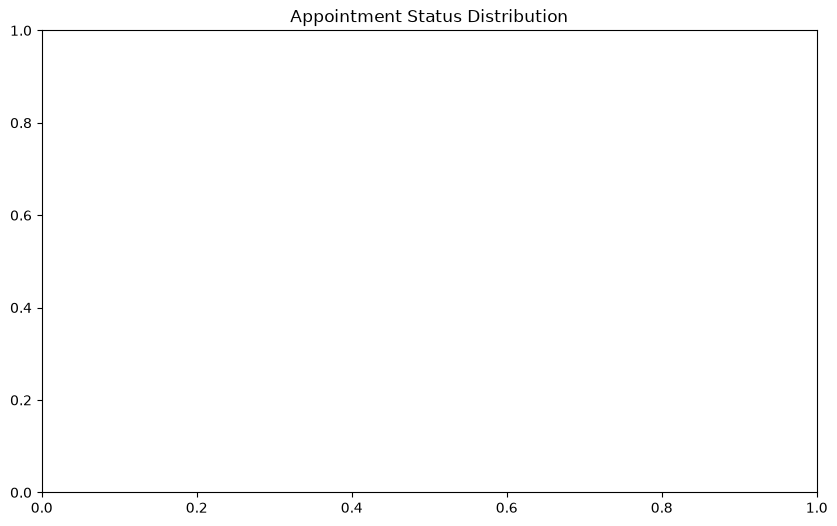

In [90]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=data, x='appointment_status')
plt.title(f'Appointment Status Distribution')
plt.show()

In [91]:
plt.show()

In [92]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

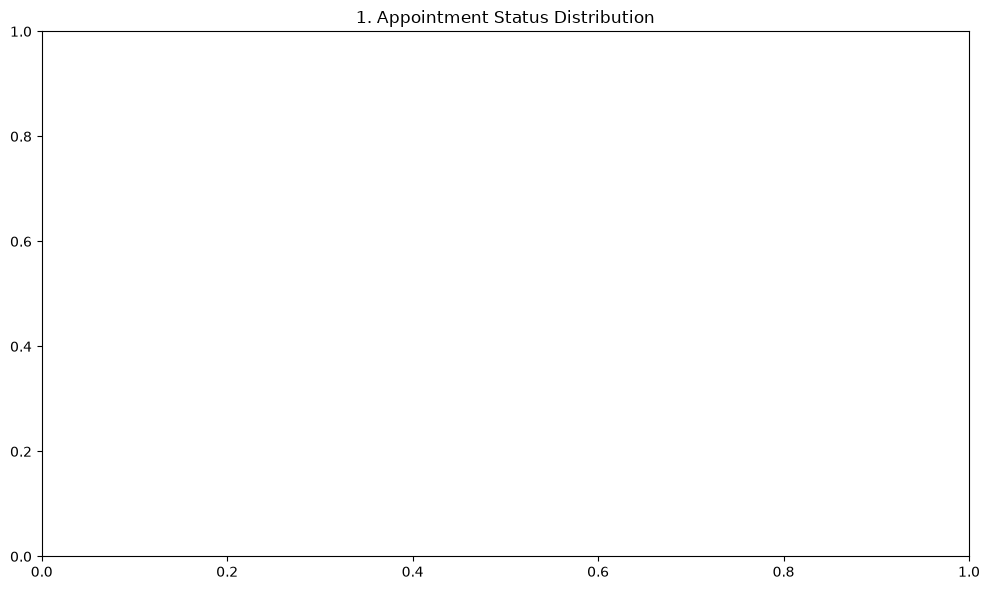

In [95]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=data, x='appointment_status')
plt.title(f'{plot_no}. Appointment Status Distribution')
show_fig()
plot_no += 1

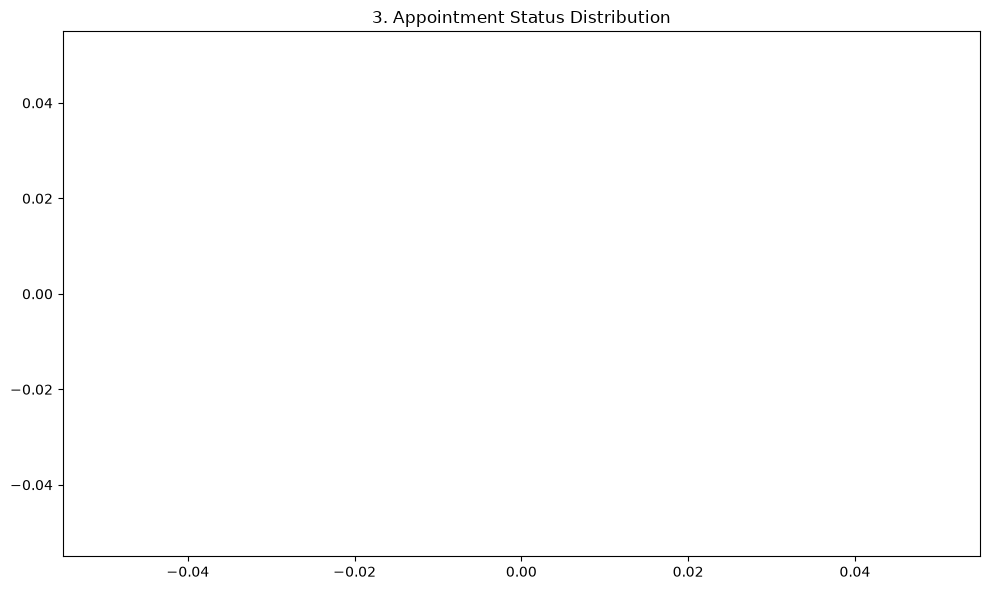

In [98]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="appointment_status")
plt.title(f'{plot_no}. Appointment Status Distribution')
show_fig()
plot_no += 1